
# Mock Data + Multi-Output GP Regressor Example

In [1]:
import sys
from pathlib import Path

project_root = Path(r"c:\Users\floki\PycharmProjects\dash-azure-prototype")
src_root = project_root / "src"
for p in (project_root, src_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
artifact_dir = project_root / "ml" / "models" / "artifacts" / "demo_artifact"

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

In [3]:
from ml.scripts.plotting import (
    plot_true_vs_predicted,
    plot_pca_cumulative_variance,
    plot_pca_loadings,
)
from ml.scripts.trainers import MultiTaskGPTrainer
from ml.scripts.metrics import mape, picp
from ml.scripts.log import init_ml_logger, log_data_summary
from worker.models.models import MultiOutputExactGP
from worker.models.specs import ModelConfig, PreprocessConfig, AuxilaryData
from worker.models.io_utils import ArtifactIO
from worker.torch_utils import get_default_device

In [4]:
# load demo data for testing
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(DATA_URL)
df = df.rename(columns=lambda c: str(c).strip())
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
# train test split
feature_cols = list(df.columns[:8])
target_cols = list(df.columns[8:10])

X = df[feature_cols].to_numpy()
y = df[target_cols].to_numpy()

train_x, test_x, train_y, test_y = train_test_split(
    X, y, test_size=0.1, random_state=42
)

train_x_raw = train_x.copy()
test_x_raw = test_x.copy()
y_train_raw = train_y.copy()
y_test_raw = test_y.copy()

In [6]:
# drop features without variance
var_x = VarianceThreshold(threshold=1e-6)
train_x = var_x.fit_transform(train_x)
test_x = var_x.transform(test_x)
kept_mask_x = var_x.get_support()
feature_cols = [c for c, keep in zip(feature_cols, kept_mask_x) if keep]

In [7]:
# feature scaling
scaler_x = StandardScaler()
train_x = scaler_x.fit_transform(train_x)
test_x = scaler_x.transform(test_x)

In [8]:
# PCA fit/transform
pca_x = PCA(whiten=False, n_components=0.999, random_state=1)
train_x = pca_x.fit_transform(train_x)
test_x = pca_x.transform(test_x)

In [9]:
# target scaling
scaler_y = MinMaxScaler()
train_y = scaler_y.fit_transform(train_y)
test_y = scaler_y.transform(test_y)

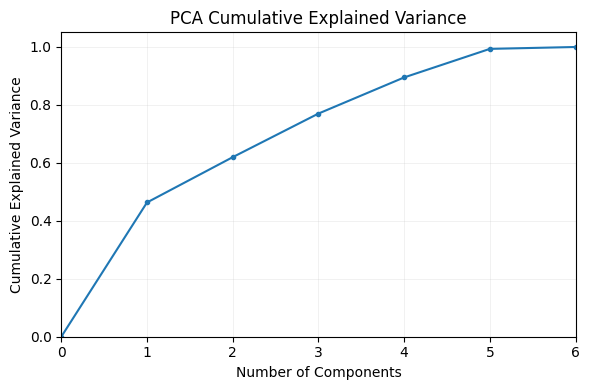

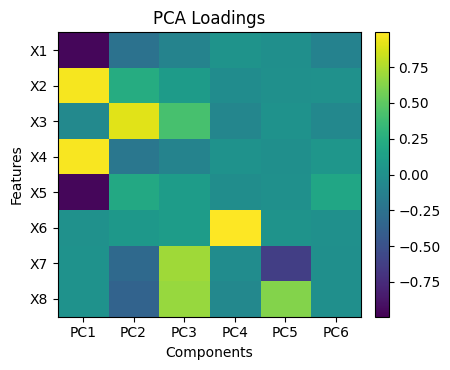

In [10]:
# PCA diagnostics
plots_dir = artifact_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
_ = plot_pca_cumulative_variance(pca=pca_x, filepath=plots_dir / "pca_cumvar.png")
_ = plot_pca_loadings(pca=pca_x, feature_names=feature_cols, filepath=plots_dir / "pca_loadings.png")

In [11]:
# setup model
prep = PreprocessConfig(scaler_x=scaler_x, pca_x=pca_x, scaler_y=scaler_y)
noise_rank = 1
covar_rank = 2
spec = ModelConfig(
    model_type="multitask_gp",
    features=feature_cols,
    targets=target_cols,
    model_kwargs={"covar_rank": covar_rank, "noise_rank": noise_rank},
)
aux = AuxilaryData(train_x=train_x, train_y=train_y)
model = MultiOutputExactGP(spec, aux, prep=prep)

In [12]:
# conduct training
device = get_default_device()
print(f"Running on {str(device)}")
trainer = MultiTaskGPTrainer(model, device=device, lr=0.01)
metrics = trainer.train(train_x, train_y, epochs=600)

Running on cuda


GP training:   0%|          | 0/600 [00:00<?, ?it/s]

In [13]:
# check if storing / loading of artifacts works
ArtifactIO.save(artifact_dir, model=model, spec=spec, prep=prep, aux=aux)
loaded_model = ArtifactIO.load(artifact_dir, device=device)

In [14]:
# test predictions on test set
preds = loaded_model.predict(test_x_raw, device=device, return_std=True)
if isinstance(preds, dict):
    pred_mean = preds.get('mean')
    pred_std = preds.get('std')
else:
    pred_mean = preds
    pred_std = None

preds_train = loaded_model.predict(train_x_raw, device=device, return_std=True)
if isinstance(preds_train, dict):
    pred_mean_train = preds_train.get('mean')
    pred_std_train = preds_train.get('std')
else:
    pred_mean_train = preds_train
    pred_std_train = None

mape_val = mape(y_test_raw, pred_mean)
r2 = r2_score(y_test_raw, pred_mean, multioutput='uniform_average')

if pred_std is not None:
    picp_val = picp(y_test_raw, y_pred=pred_mean, y_std=pred_std)
else:
    picp_val = None

print(f'MAPE: {mape_val:.4f}%')
print(f'R2: {r2:.4f}')
if picp_val is not None:
    print(f'PICP (95%): {picp_val:.4f}')

MAPE: 0.0348%
R2: 0.9860
PICP (95%): 0.9870


In [15]:
logger, _ = init_ml_logger(artifact_dir, "training")
if logger is not None:
    logger.info("Training time (s): %.3f", trainer.duration)
    log_data_summary(
        logger,
        y_train_raw,
        y_pred=pred_mean_train,
        y_std=pred_std_train,
        feature_cols=feature_cols,
        target_cols=target_cols,
        phase="Train",
    )
    log_data_summary(
        logger,
        y_test_raw,
        y_pred=pred_mean,
        y_std=pred_std,
        feature_cols=feature_cols,
        target_cols=target_cols,
        phase="Test",
    )

2026-03-30 13:23:33,664 | INFO | Training time (s): 94.034
2026-03-30 13:23:33,665 | INFO | Train start: n_obs=691 n_features=8 n_targets=2 non_nan_targets=1382
2026-03-30 13:23:33,667 | INFO | Train metrics per target:
2026-03-30 13:23:33,668 | INFO |   Y1 | R2=0.9951 MAPE=0.0240 PICP(95%)=1.0000
2026-03-30 13:23:33,669 | INFO |   Y2 | R2=0.9883 MAPE=0.0281 PICP(95%)=0.9884
2026-03-30 13:23:33,671 | INFO | Test start: n_obs=77 n_features=8 n_targets=2 non_nan_targets=154
2026-03-30 13:23:33,672 | INFO | Test metrics per target:
2026-03-30 13:23:33,673 | INFO |   Y1 | R2=0.9918 MAPE=0.0300 PICP(95%)=1.0000
2026-03-30 13:23:33,674 | INFO |   Y2 | R2=0.9802 MAPE=0.0396 PICP(95%)=0.9740


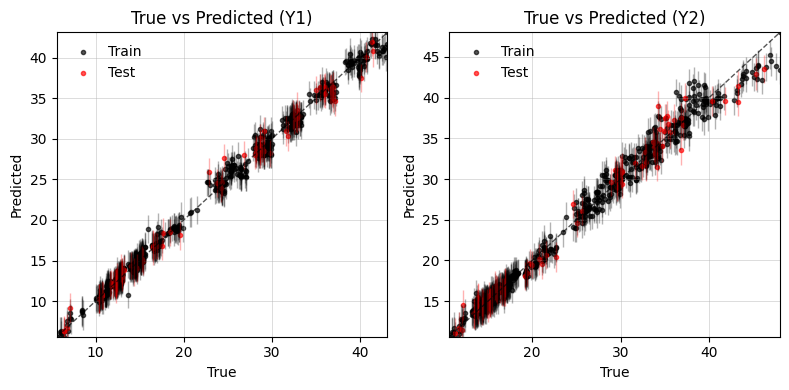

In [16]:
plots_dir = artifact_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
fig = plot_true_vs_predicted(
    y_train_raw,
    pred_mean_train,
    y_std=pred_std_train,
    y_true_test=y_test_raw,
    y_pred_test=pred_mean,
    y_std_test=pred_std,
    target_cols=target_cols,
    show_std=pred_std is not None or pred_std_train is not None,
    filepath=plots_dir / "true_vs_pred.png",
)